In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Data/staff_turnover_HR_cleaned.csv')
df.head()

,EmpID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,AgeGroup,SalarySlab
0,RM650,53,No,Travel_Rarely,Research & Development,23,Life Sciences,4,Female,Research Director,...,3,3,33,0,3,12,9,3,46-55,10k-15k
1,RM015,28,Yes,Travel_Rarely,Research & Development,24,Life Sciences,3,Male,Laboratory Technician,...,3,2,6,4,3,4,2,0,26-35,Upto 5k
2,RM1111,35,Yes,Travel_Rarely,Research & Development,2,Life Sciences,1,Female,Laboratory Technician,...,3,4,1,2,3,1,0,0,26-35,Upto 5k
3,RM1438,39,No,Non_Travel,Research & Development,9,Life Sciences,4,Male,Manager,...,3,3,21,3,2,6,0,1,36-45,15k+
4,RM311,31,No,Travel_Rarely,Human Resources,2,Human Resources,1,Male,Human Resources,...,3,4,9,1,3,2,2,1,26-35,5k-10k


In [11]:
df_attrition = df.groupby('Attrition')['EmpID'].count().sort_values(ascending=False).reset_index(name='Cantidad')#.plot(kind='bar', color=['green', 'red'])
df_attrition

,Attrition,Cantidad
0,No,1236
1,Yes,237


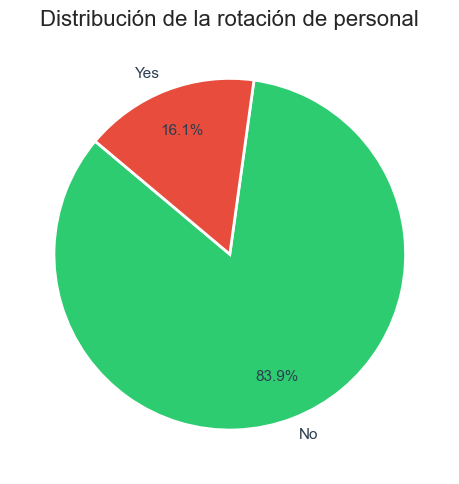

In [44]:
plt.figure(figsize=(6, 5))
colores = ["#2ecc71", "#e74c3c"]

wedges, texts, autotexts = plt.pie(
    df_attrition['Cantidad'],
    labels=df_attrition['Attrition'],
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    pctdistance=0.75,
    textprops={"fontsize": 11, "color": "#2C3E50"},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title('Distribución de la rotación de personal', fontsize=16)
plt.tight_layout() 
plt.show()


In [61]:
df_Department_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
df_Department_attrition = df_Department_attrition.style.format("{:.1%}")
df_Department_attrition

Attrition,No,Yes
Department,,
Human Resources,81.0%,19.0%
Research & Development,86.2%,13.8%
Sales,79.4%,20.6%


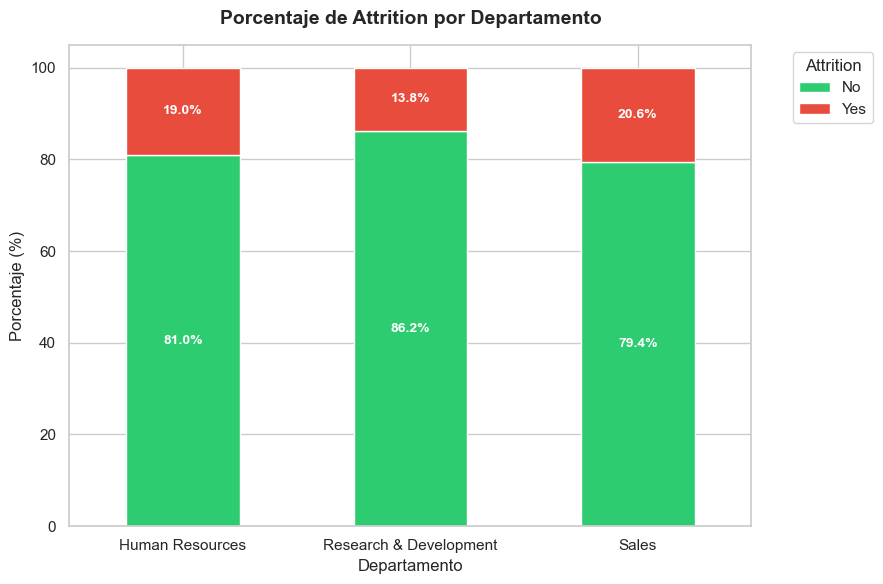

In [67]:
df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100

ax = df_datos.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Departamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [70]:
df_Gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack()
df_Gender_attrition = df_Gender_attrition.style.format("{:.1%}")
df_Gender_attrition

Attrition,No,Yes
Gender,,
Female,85.2%,14.8%
Male,83.0%,17.0%


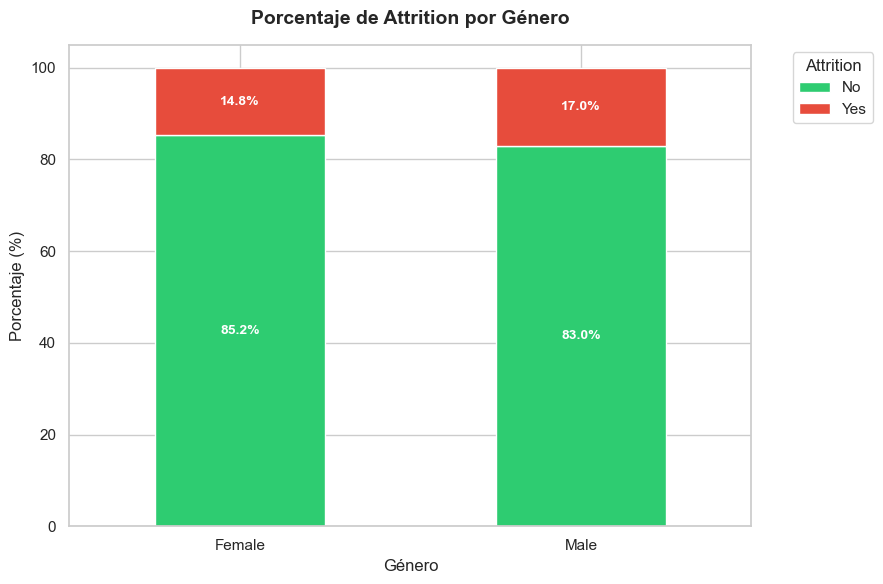

In [71]:
df_Gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack() * 100

ax = df_Gender_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Género', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [72]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
df_jobrole_attrition = df_jobrole_attrition.style.format("{:.1%}")
df_jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.2%,6.8%
Human Resources,76.9%,23.1%
Laboratory Technician,76.1%,23.9%
Manager,95.1%,4.9%
Manufacturing Director,93.1%,6.9%
Research Director,97.5%,2.5%
Research Scientist,84.0%,16.0%
Sales Executive,82.5%,17.5%
Sales Representative,60.7%,39.3%


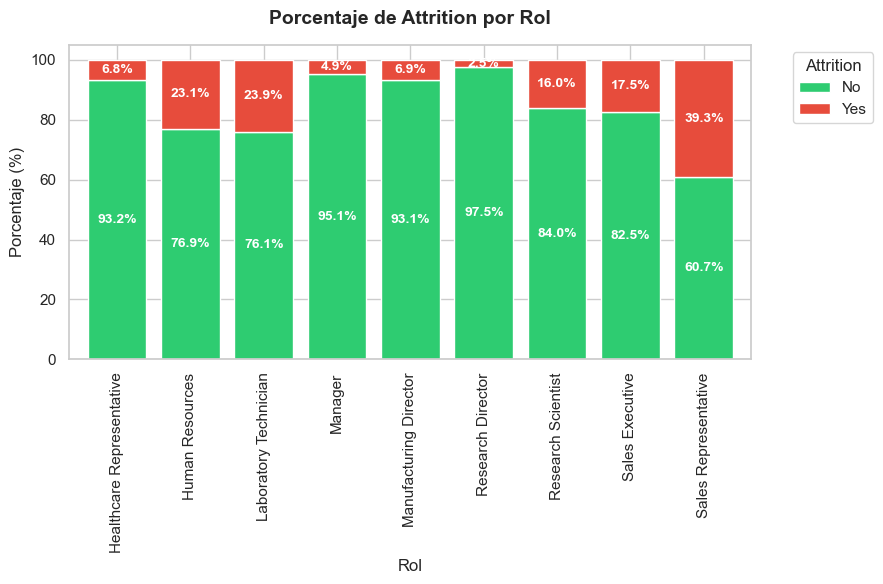

In [82]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100

ax = df_jobrole_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Rol', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rol', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=90) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [83]:
df_jobSatisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack()
df_jobSatisfaction_attrition = df_jobSatisfaction_attrition.style.format("{:.1%}")
df_jobSatisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.2%,22.8%
2,83.6%,16.4%
3,83.5%,16.5%
4,88.7%,11.3%


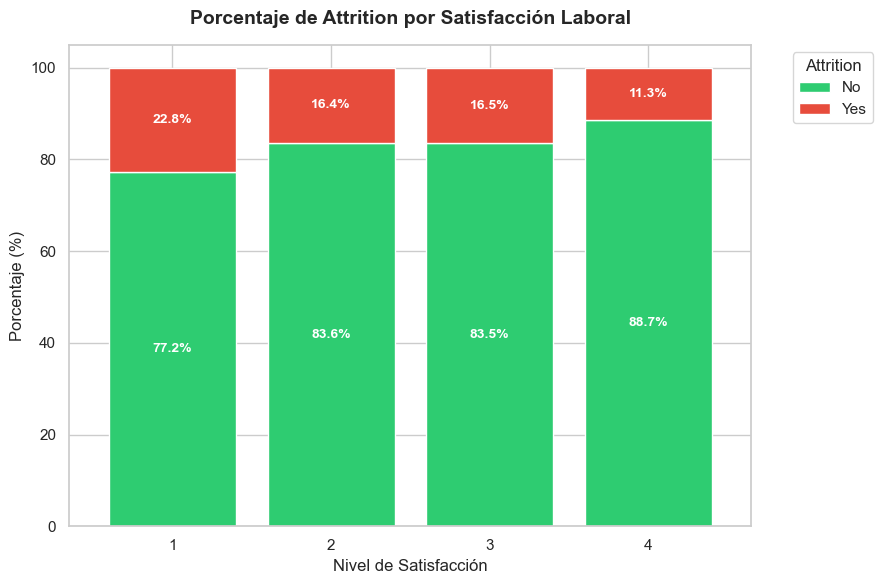

In [86]:
df_jobSatisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100

ax = df_jobSatisfaction_attrition.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Satisfacción Laboral', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Satisfacción', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
